In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("movies.csv")
df.head()

,Unnamed: 0,Movie Name,Year of Release,Watch Time,Movie Rating,Meatscore of movie,Votes,Gross,Description
0,0,The Shawshank Redemption,(1994),142 min,9.3,81,"34,709",$28.34M,Two imprisoned men bond over a number of years...
1,1,The Godfather,(1972),175 min,9.2,100,"34,709",$134.97M,The aging patriarch of an organized crime dyna...
2,2,The Dark Knight,(2008),152 min,9.0,84,"34,709",$534.86M,When the menace known as the Joker wreaks havo...
3,3,The Lord of the Rings: The Return of the King,(2003),201 min,9.0,94,"34,709",$377.85M,Gandalf and Aragorn lead the World of Men agai...
4,4,Schindler's List,(1993),195 min,9.0,94,"34,709",$96.90M,"In German-occupied Poland during World War II,..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1000 non-null   int64  
 1   Movie Name          1000 non-null   object 
 2   Year of Release     1000 non-null   object 
 3   Watch Time          1000 non-null   object 
 4   Movie Rating        1000 non-null   float64
 5   Meatscore of movie  1000 non-null   object 
 6   Votes               1000 non-null   object 
 7   Gross               1000 non-null   object 
 8   Description         1000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

Unnamed: 0            0
Movie Name            0
Year of Release       0
Watch Time            0
Movie Rating          0
Meatscore of movie    0
Votes                 0
Gross                 0
Description           0
dtype: int64

In [7]:

import re


def extract_numeric(value):
    if pd.isna(value):  
        return value
    
    numeric_string = re.sub(r'[^0-9.]', '', str(value))
    
    return numeric_string if numeric_string else np.nan


df['Gross'] = df['Gross'].apply(extract_numeric)


df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')



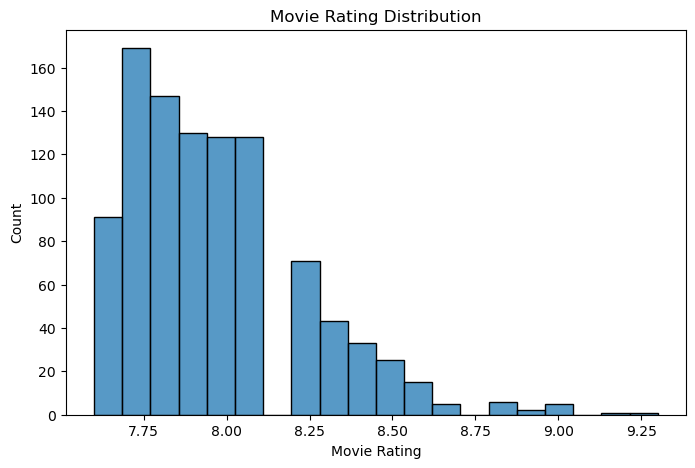

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Movie Rating'], bins=20)
plt.title("Movie Rating Distribution")
plt.show()

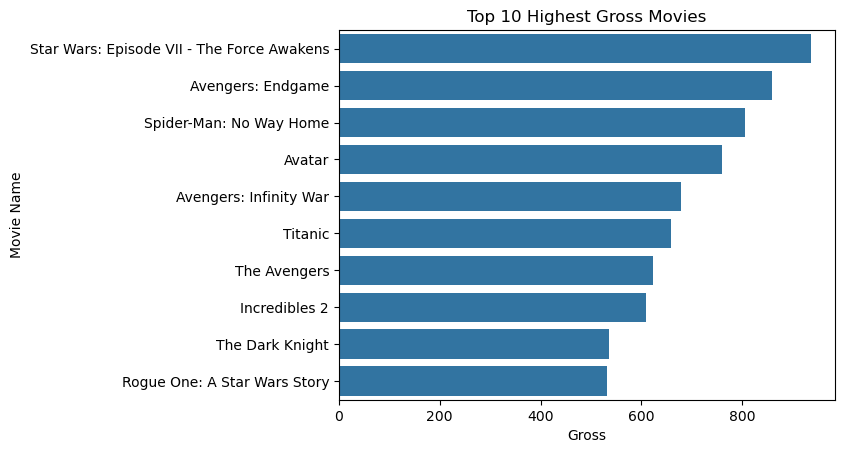

In [9]:
top_movies = df.sort_values(by='Gross', ascending=False).head(10)

sns.barplot(x='Gross', y='Movie Name', data=top_movies)
plt.title("Top 10 Highest Gross Movies")
plt.show()

In [10]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\pooji\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [12]:
df['sentiment_score'] = df['Description'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

In [13]:
df['sentiment'] = df['sentiment_score'].apply(lambda x: "Positive" if x > 0 else "Negative")

In [14]:
df[['Movie Name','sentiment','sentiment_score']].head()

,Movie Name,sentiment,sentiment_score
0,The Shawshank Redemption,Negative,-0.4019
1,The Godfather,Negative,-0.6705
2,The Dark Knight,Negative,-0.8176
3,The Lord of the Rings: The Return of the King,Negative,-0.4019
4,Schindler's List,Negative,-0.5994


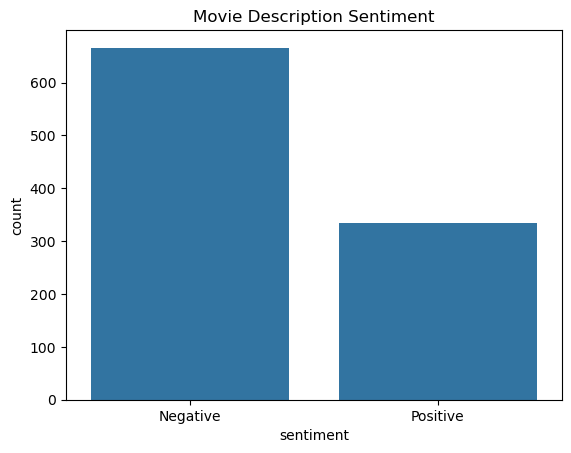

In [15]:
sns.countplot(x='sentiment', data=df)
plt.title("Movie Description Sentiment")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [24]:
X = df[['Movie Rating','Meatscore of movie']]
y = df['Gross']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = df['Votes'].astype(int)

In [28]:
df['Gross'] = df['Gross'].astype(str)
df['Gross'] = df['Gross'].str.replace('$','')
df['Gross'] = df['Gross'].str.replace('M','')
df['Gross'] = df['Gross'].astype(float)

In [29]:
X = df[['Movie Rating','Meatscore of movie','Votes']]
y = df['Gross']

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Assuming X is your feature dataframe and y is your target variable
# First, let's handle the NaN values in y
# Drop rows where y has NaN values
mask = ~np.isnan(y)
X = X[mask]
y = y[mask]

# Now identify which columns are numeric and which are categorical
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Create a preprocessor that will handle both numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline that first preprocesses the data and then applies the model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['Movie Rating', 'Votes'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Meatscore of movie'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [33]:
predictions = model.predict(X_test)

In [34]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,predictions)
print("MSE:", mse)

MSE: 14645.479435429881


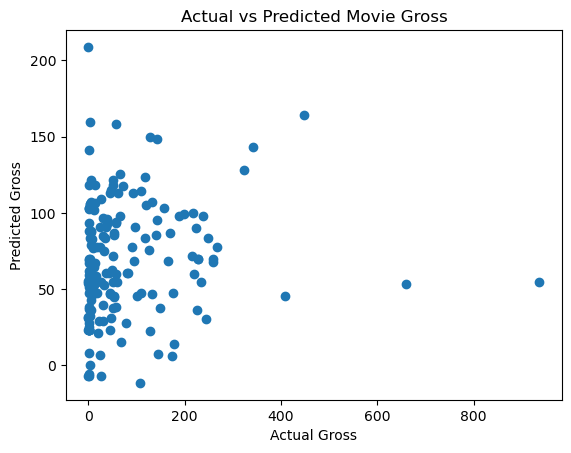

In [35]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Gross")
plt.ylabel("Predicted Gross")
plt.title("Actual vs Predicted Movie Gross")
plt.show()